In [1]:
import os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# preallocate 95% of the GPU memory
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'
import jax
from jax import config
import numpy as np
from discodj import DiscoDJ
import jax.numpy as jnp
from jax._src.lib import xla_client
import sys
import gc

devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
# device = "cpu"
root = "/mnt/ceph/users/spandey/discodj_runs/LH/"

dim = 3
precision = "single"
# Define the boxsize and resolution
boxsize = 1000.0  # in Mpc/h
res = 640  # the particles live on a Lagrangrian grid of resolution (res)^dim
factor = 2
n_order = 2
a_ic = 1./128.
numsteps = 20  # number of steps to be performed
a_end = 1./1.5
Ob = 0.049
# stepper = "bullfrog"
stepper = "fastpm"
method = "pm"
res_pm = factor * res
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 1
deconvolve = False
nlpt_order_ics = n_order
chunk_size = None




ERROR:2025-12-19 16:35:38,206:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/mnt/home/spandey/ceph/env/discodj/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/mnt/home/spandey/ceph/env/discodj/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/mnt/home/spandey/ceph/env/discodj/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


In [ ]:
def run_one_simulation(sim_id):
        path_ic = root + "%d/ICs"%(sim_id)
        path_pm = root + "%d/pm"%(sim_id)
        os.makedirs(path_pm, exist_ok=True)

        # read Cosmo_params.dat file to get cosmological parameters:
        cosmo_all = np.loadtxt(path_ic + "/Cosmo_params.dat", delimiter=' ')



        Om = cosmo_all[0]
        Ob = cosmo_all[1]
        h = cosmo_all[2]
        ns = cosmo_all[3]
        sigma8 = cosmo_all[4]
        Oc = Om - Ob

        # if not(os.path.exists(path_pm)):  os.system('mkdir %s'%path_pm)
        ic_delta = np.load(path_ic+"/IC_delta640.npy")
        ic_delta = jnp.array(ic_delta, dtype=jnp.float32)

        cosmo = dict(Omega_c=Oc,  # cold dark matter content
                        Omega_b=Ob,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
                        h=h,  # dimensionless Hubble constant
                        n_s=ns,  # scalar spectral index
                        sigma8=sigma8  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
                        )

        dj = DiscoDJ(dim=dim, res=res, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)

        # Compute the linear power spectrum
        dj = dj.with_timetables()
        Dplus_aic = np.interp(jnp.log10(a_ic), jnp.log10(dj.cosmo._timetables['a']), dj.cosmo._timetables['Dplus'])

        dj = dj.with_external_ics(delta = ic_delta/Dplus_aic)
        dj = dj.with_lpt(n_order=n_order, try_to_jit=True)

        X_sim, P_sim, _ = dj.run_nbody(
                a_ini=a_ic, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                time_var=time_var, stepper=stepper, method=method,
                antialias=antialias, grad_kernel_order=grad_kernel_order,
                laplace_kernel_order=laplace_kernel_order,
                nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                deconvolve=deconvolve, return_displacement=False,
                chunk_size=chunk_size)
        # convert to km/s
        P_sim = P_sim / a_end * 100.
        X_sim = np.array(X_sim, dtype=np.float16)
        P_sim = np.array(P_sim, dtype=np.float16)
        X_sim = np.reshape(X_sim, (-1,3))
        P_sim = np.reshape(P_sim, (-1,3))

        print("Saving to %s"%(path_pm))
        # np.savez_compressed(path_pm + "/sim_LH%d_z05.npz" % (sim_id), pos=X_sim, vel=P_sim)
        np.save(path_pm+"/pos_LH%d_z05.npy"%sim_id,X_sim)
        np.save(path_pm+"/vel_LH%d_z05.npy"%sim_id,P_sim)

        print("Simulation %d done."%(sim_id))


        del dj, ic_delta, X_sim, P_sim
        gc.collect()
        jax.clear_caches()
        return



In [5]:
run_one_simulation(0)

# for i in range(1):
#     run_one_simulation(i)






Saving to /mnt/ceph/users/spandey/discodj_runs/LH/0/pm
Simulation 0 done.


In [ ]:
sdir = '/mnt/ceph/users/spandey/discodj_runs/LH/0/pm'
dfp = np.load(f'{sdir}/pos_LH0_z05.npy')



In [20]:
import MAS_library as MASL

def save_cic_densities(ji):
    # try:
    root_in = '/mnt/ceph/users/spandey/discodj_runs/LH/%d/pm' % ji
    root_out = '/mnt/ceph/users/spandey/discodj_runs/rhog_LH/%d/' % ji
    os.makedirs(root_out, exist_ok=True)
    grid         = 512
    BoxSize = 1000.0 #Mpc/h ; size of box
    BoxSize = 1000.0    
    pos = np.load(root_in + '/pos_LH%d_z05.npy' % ji)
    pvel = np.load(root_in + '/vel_LH%d_z05.npy' % ji)                           
    
    # pos = np.array(df['Position'], dtype=np.float64)
    rho_m_orig = np.zeros((grid,grid,grid), dtype=np.float32)
    MASL.MA(np.float32(pos), rho_m_orig, BoxSize, 'CIC', verbose=False)
    

    mom_m_x_orig = np.zeros((grid,grid,grid), dtype=np.float32)                
    MASL.MA(np.float32(pos), mom_m_x_orig, BoxSize, 'CIC', verbose=False, W=pvel[:,0].astype(np.float32))
    mom_m_y_orig = np.zeros((grid,grid,grid), dtype=np.float32)                
    MASL.MA(np.float32(pos), mom_m_y_orig, BoxSize, 'CIC', verbose=False, W=pvel[:,1].astype(np.float32))
    mom_m_z_orig = np.zeros((grid,grid,grid), dtype=np.float32)                
    MASL.MA(np.float32(pos), mom_m_z_orig, BoxSize, 'CIC', verbose=False, W=pvel[:,2].astype(np.float32))                

    vel_m_x_orig = mom_m_x_orig/rho_m_orig
    vel_m_y_orig = mom_m_y_orig/rho_m_orig
    vel_m_z_orig = mom_m_z_orig/rho_m_orig

    # at voxels with non-finite values, set velocities to zero:
    vel_m_x_orig[~np.isfinite(vel_m_x_orig)] = 0.0
    vel_m_y_orig[~np.isfinite(vel_m_y_orig)] = 0.0
    vel_m_z_orig[~np.isfinite(vel_m_z_orig)] = 0.0

    # divide out by 1000.:
    vel_m_x_orig /= 100.
    vel_m_y_orig /= 100.
    vel_m_z_orig /= 100.

    vel_m_all_orig = np.stack((vel_m_x_orig, vel_m_y_orig, vel_m_z_orig), axis=0).astype(np.float16)
    rho_m_orig = (rho_m_orig / 100.).astype(np.float16)
    print(np.amin(vel_m_all_orig), np.amax(vel_m_all_orig))
    print(np.amax(rho_m_orig), np.min(rho_m_orig))
    np.save(root_out+"/rho_grid_%d_LH%d_z05.npy"%(grid, ji), rho_m_orig)
    np.save(root_out+"/vel_grid_%d_LH%d_z05.npy"%(grid, ji), vel_m_all_orig)
    return


In [21]:
save_cic_densities(1)




/tmp/ipykernel_483027/1508781113.py:26: RuntimeWarning: invalid value encountered in divide
  vel_m_x_orig = mom_m_x_orig/rho_m_orig
/tmp/ipykernel_483027/1508781113.py:27: RuntimeWarning: invalid value encountered in divide
  vel_m_y_orig = mom_m_y_orig/rho_m_orig
/tmp/ipykernel_483027/1508781113.py:28: RuntimeWarning: invalid value encountered in divide
  vel_m_z_orig = mom_m_z_orig/rho_m_orig


-20.02 22.62
14.94 0.0


In [ ]:
import numpy as np
import MAS_library as MASL

# density field parameters
grid    = 256    #the 3D field will have grid x grid x grid voxels
BoxSize = 1000.0 #Mpc/h ; size of box
MAS     = 'CIC'  #mass-assigment scheme
verbose = True   #print information on progress

delta_dj = np.zeros((grid,grid,grid), dtype=np.float32)

# construct 3D density field
MASL.MA(dfp.astype(np.float32), delta_dj, BoxSize, MAS, verbose=verbose)


# at this point, delta contains the effective number of particles in each voxel
# now compute overdensity and density constrast
# delta_dj /= np.mean(delta_dj, dtype=np.float32);  delta_dj -= 1.0



Using CIC mass assignment scheme
Time taken = 3.832 seconds



In [9]:
import numpy as np
import readgadget

# input files
snapshot = '/mnt/home/fvillaescusa/ceph/Quijote/Snapshots/latin_hypercube_HR/0/snapdir_003/snap_003'
ptype    = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)

# read positions, velocities and IDs of the particles
posq = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h



In [10]:
delta_q = np.zeros((grid,grid,grid), dtype=np.float32)

# construct 3D density field
MASL.MA(posq, delta_q, BoxSize, MAS, verbose=verbose)




Using CIC mass assignment scheme
Time taken = 15.568 seconds



In [11]:
delta_q /= np.mean(delta_q, dtype=np.float32);  delta_q -= 1.0



In [22]:
import Pk_library as PKL

Pk = PKL.XPk([delta_dj,delta_q], BoxSize, 0, MAS=['CIC','CIC'], threads=1)




Computing power spectra of the fields...
Time FFTS = 0.39
Time loop = 0.31
Time taken = 0.70 seconds


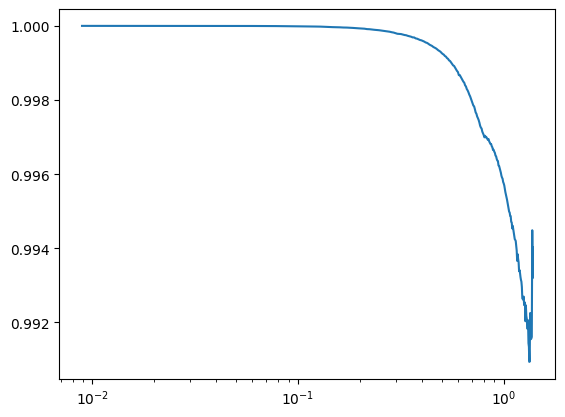

In [23]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(Pk.k3D, Pk.XPk[:,0,0]/np.sqrt(Pk.Pk[:,0,0] * Pk.Pk[:,0,1]), label='Disco-DJ')
plt.xscale('log')


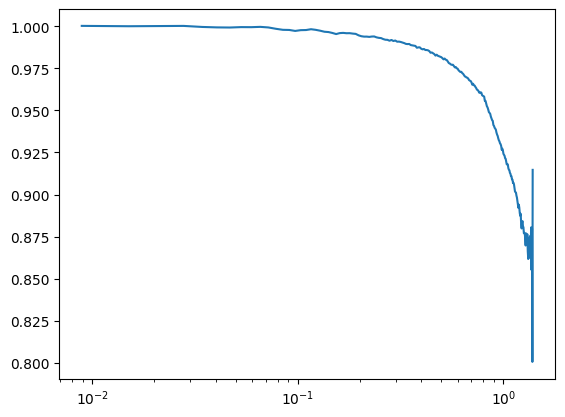

In [24]:
plt.figure()
plt.plot(Pk.k3D, Pk.Pk[:,0,0] / Pk.Pk[:,0,1], label='Disco-DJ')
plt.xscale('log')


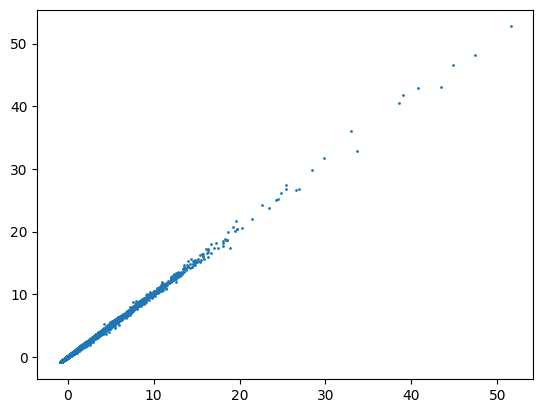

In [25]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(delta_dj.flatten()[::100], delta_q.flatten()[::100], s=1)



In [27]:
import numpy as np
import os, sys
from tqdm import tqdm

js_min = 0
js_max = 2000
js_all = np.arange(js_min, js_max).astype(int)

sdir_base = '/mnt/ceph/users/spandey/discodj_runs/LH'

for js in tqdm(js_all):

    # check if the directory exists, else create it:
    sdir = sdir_base + '/%d/'%js
    sdir_IC = sdir_base + '/%d/ICs'%js
    os.makedirs(sdir, exist_ok=True)
    os.makedirs(sdir_IC, exist_ok=True)

    ldir = '/mnt/home/fvillaescusa/ceph/Quijote/Snapshots/latin_hypercube_HR/' + str(js)
    Pkmm_z0_file_orig = ldir + '/ICs/Pk_mm_z=0.000.txt'
    os.system('cp %s %s'%(Pkmm_z0_file_orig, sdir_IC + '/Pk_mm_z=0.000.txt'))

    cosmo_params_orig = ldir + '/Cosmo_params.dat'
    os.system('cp %s %s'%(cosmo_params_orig, sdir_IC + '/Cosmo_params.dat'))

    ffile_orig = open(ldir + '/ICs/2LPT.param', 'r')
    f = ffile_orig.readlines()
    ffile_orig.close()

    variables_all = ['Seed', 'Omega ', 'OmegaLambda ', 'OmegaBaryon ', 'OmegaDM_2ndSpecies ', 'HubbleParam ', 'Redshift', 'Sigma8']
    values_all = {}
    g = ''   
    for variable in variables_all:
        for line in f:        
            if variable in line:
                # print(line.split())
                if variable == 'Seed':
                    value = int(line.split()[1])
                else:
                    value = float(line.split()[1])
                values_all[variable] = value

    ffile = open('/mnt/ceph/users/spandey/quijote_v2_gotham/GOTHAM/ICs/2LPT_base.param', 'r')
    f = ffile.readlines()
    ffile.close()

    g = ''   
    for line in f:
        for variable in variables_all:
            if variable in line:
                # print(line.split())
                value = values_all[variable]
                line = line.replace(line.split()[1], str(value))
                # print(line)

        g += line
            
    ffile = open(sdir_IC + '/2LPT.param', 'w')
    ffile.write(g)
    ffile.close()



  0%|          | 0/2000 [00:00<?, ?it/s]cp: cannot create regular file '/mnt/ceph/users/spandey/discodj_runs/LH/0/ICs/Pk_mm_z=0.000.txt': Permission denied
cp: cannot create regular file '/mnt/ceph/users/spandey/discodj_runs/LH/0/ICs/Cosmo_params.dat': Permission denied
  0%|          | 1/2000 [00:00<03:27,  9.64it/s]cp: cannot create regular file '/mnt/ceph/users/spandey/discodj_runs/LH/1/ICs/Pk_mm_z=0.000.txt': Permission denied
cp: cannot create regular file '/mnt/ceph/users/spandey/discodj_runs/LH/2/ICs/Pk_mm_z=0.000.txt': Permission denied
  0%|          | 3/2000 [00:00<02:36, 12.74it/s]cp: cannot create regular file '/mnt/ceph/users/spandey/discodj_runs/LH/3/ICs/Pk_mm_z=0.000.txt': Permission denied
cp: cannot create regular file '/mnt/ceph/users/spandey/discodj_runs/LH/4/ICs/Pk_mm_z=0.000.txt': Permission denied
  0%|          | 5/2000 [00:00<02:52, 11.59it/s]cp: cannot create regular file '/mnt/ceph/users/spandey/discodj_runs/LH/5/ICs/Pk_mm_z=0.000.txt': Permission denied
cp: c

In [30]:
import numpy as np
import os
from tqdm import tqdm

points = 2000

# numbers = np.where(np.arange(points)%nprocs==myrank)[0]
numbers = np.arange(points)

for sim_id in tqdm(numbers):
    #nfiles = 8
    nfiles = 64
    path = f'/mnt/ceph/users/spandey/discodj_runs/LH/{sim_id}/ICs/'
    savefname = path+'IC_delta640.npy'

    # check if the file already exists
    if os.path.exists(savefname):
        continue

    try:
        #path = f'/work/hdd/bdne/yzhang116/ICsSAM/cLH{sim_id:d}/ICs/'
        #path = f'/work/hdd/bdne/yzhang116/CV/CV_{sim_id:d}/ICs/'
        
        idx = []
        amp, phase = [], []
        print("\nConvert for path: ", path)

        for i in range(nfiles):
            # read a particular coordinate file
            f_in = path + 'Coordinates_ptype_1.%d'%i
            f = open(f_in, 'rb')
            Nfiles = np.fromfile(f, dtype=np.int32, count=1)[0] #Number of coordinate subfiles  
            Nmesh  = np.fromfile(f, dtype=np.int32, count=1)[0] #Nmesh size
            Nx     = np.fromfile(f, dtype=np.int32, count=1)[0] #slab offset (not used)
            coordinates = np.fromfile(f, dtype=np.int64, count=-1)
            kx = (coordinates//(Nmesh//2 + 1))//Nmesh
            ky = (coordinates//(Nmesh//2 + 1))%Nmesh
            kz = (coordinates%(Nmesh//2 + 1))%Nmesh
            kk = np.array([kx, ky, kz]).T
            idx.append(kk)

            f_in = path + 'Amplitudes_ptype_1.%d'%i
            f = open(f_in,'rb')
            Nfiles = np.fromfile(f, dtype=np.int32, count=1)[0] #Number of coordinate subfiles  
            Nmesh  = np.fromfile(f, dtype=np.int32, count=1)[0] #Nmesh size
            Nx     = np.fromfile(f, dtype=np.int32, count=1)[0] #slab offset (not used)
            aa = np.fromfile(f, dtype=np.float32, count=-1)
            amp.append(aa)
            f_in = path + 'Phases_ptype_1.%d'%i
            f = open(f_in,'rb')
            Nfiles = np.fromfile(f, dtype=np.int32, count=1)[0] #Number of coordinate subfiles  
            Nmesh  = np.fromfile(f, dtype=np.int32, count=1)[0] #Nmesh size
            Nx     = np.fromfile(f, dtype=np.int32, count=1)[0] #slab offset (not used)
            phase.append(np.fromfile(f, dtype=np.float32, count=-1))
    except:
        pass

    idx = np.concatenate(idx)
    amp = np.concatenate(amp)
    phase = np.concatenate(phase)

    val = amp*np.exp(1j*phase)
    cmesh = val.reshape(Nmesh, Nmesh, kz.max()+1)

    bs=1000     #Mpc/h
    mesh = np.fft.irfftn(cmesh, norm='ortho') * Nmesh**1.5
    #np.save(path+'IC_delta128_cLH%d.npy'%sim_id, mesh.astype(np.float32))
    np.save(savefname, mesh.astype(np.float32))


    for i in range(nfiles):
        os.remove(path + 'Coordinates_ptype_1.%d'%i)
        os.remove(path + 'Amplitudes_ptype_1.%d'%i)
        os.remove(path + 'Phases_ptype_1.%d'%i)




  2%|▏         | 35/2000 [00:00<00:05, 345.34it/s]


Convert for path:  /mnt/ceph/users/spandey/discodj_runs/LH/68/ICs/


  3%|▎         | 69/2000 [00:58<32:20,  1.00s/it] 


Convert for path:  /mnt/ceph/users/spandey/discodj_runs/LH/78/ICs/


  4%|▍         | 78/2000 [01:07<27:45,  1.15it/s]


ValueError: cannot reshape array of size 20544000 into shape (640,640,321)

In [31]:
numbers = np.arange(10)
for sim_id in tqdm(numbers):
    #nfiles = 8
    nfiles = 128
    path = f'/mnt/ceph/users/spandey/discodj_runs/LH/{sim_id}/ICs/'
    for i in range(nfiles):
        try:
            os.remove(path + 'Coordinates_ptype_1.%d'%i)
            os.remove(path + 'Amplitudes_ptype_1.%d'%i)
            os.remove(path + 'Phases_ptype_1.%d'%i)
        except:
            pass
        

100%|██████████| 10/10 [00:08<00:00,  1.20it/s]


In [1]:
import os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# preallocate 95% of the GPU memory
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'
import jax
from jax import config
import numpy as np
from discodj import DiscoDJ
import jax.numpy as jnp
from jax._src.lib import xla_client
import sys
import gc

devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
# device = "cpu"
root = "/mnt/ceph/users/spandey/discodj_runs/LH/"

dim = 3
precision = "single"
# Define the boxsize and resolution
boxsize = 1000.0  # in Mpc/h
res = 640  # the particles live on a Lagrangrian grid of resolution (res)^dim
factor = 2
n_order = 2
a_ic = 1./128.
numsteps = 20  # number of steps to be performed
a_end = 1./1.5
Ob = 0.049
# stepper = "bullfrog"
stepper = "fastpm"
method = "pm"
res_pm = factor * res
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 1
deconvolve = False
nlpt_order_ics = n_order
chunk_size = None




def run_one_simulation(sim_id):
        path_ic = root + "%d/ICs"%(sim_id)
        path_pm = root + "%d/pm"%(sim_id)
        os.makedirs(path_pm, exist_ok=True)

        # read Cosmo_params.dat file to get cosmological parameters:
        cosmo_all = np.loadtxt(path_ic + "/Cosmo_params.dat", delimiter=' ')



        Om = cosmo_all[0]
        Ob = cosmo_all[1]
        h = cosmo_all[2]
        ns = cosmo_all[3]
        sigma8 = cosmo_all[4]
        Oc = Om - Ob

        # if not(os.path.exists(path_pm)):  os.system('mkdir %s'%path_pm)
        ic_delta = np.load(path_ic+"/IC_delta640.npy")
        ic_delta = jnp.array(ic_delta, dtype=jnp.float32)

        cosmo = dict(Omega_c=Oc,  # cold dark matter content
                        Omega_b=Ob,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
                        h=h,  # dimensionless Hubble constant
                        n_s=ns,  # scalar spectral index
                        sigma8=sigma8  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
                        )

        dj = DiscoDJ(dim=dim, res=res, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)

        # Compute the linear power spectrum
        dj = dj.with_timetables()
        Dplus_aic = np.interp(jnp.log10(a_ic), jnp.log10(dj.cosmo._timetables['a']), dj.cosmo._timetables['Dplus'])

        dj = dj.with_external_ics(delta = ic_delta/Dplus_aic)
        dj = dj.with_lpt(n_order=n_order, try_to_jit=True)

        X_sim, P_sim, _ = dj.run_nbody(
                a_ini=a_ic, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                time_var=time_var, stepper=stepper, method=method,
                antialias=antialias, grad_kernel_order=grad_kernel_order,
                laplace_kernel_order=laplace_kernel_order,
                nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                deconvolve=deconvolve, return_displacement=False,
                chunk_size=chunk_size)
        # convert to km/s
        P_sim = P_sim / a_end * 100.
        X_sim = np.array(X_sim, dtype=np.float16)
        P_sim = np.array(P_sim, dtype=np.float16)
        X_sim = np.reshape(X_sim, (-1,3))
        P_sim = np.reshape(P_sim, (-1,3))

        print("Saving to %s"%(path_pm))
        # np.savez_compressed(path_pm + "/sim_LH%d_z05.npz" % (sim_id), pos=X_sim, vel=P_sim)
        np.save(path_pm+"/pos_LH%d_z05.npy"%sim_id,X_sim)
        np.save(path_pm+"/vel_LH%d_z05.npy"%sim_id,P_sim)

        print("Simulation %d done."%(sim_id))


        del dj, ic_delta, X_sim, P_sim
        gc.collect()
        jax.clear_caches()
        return





In [2]:
# clear up jax caches
jax.clear_caches()
gc.collect()

# sim_id = int(sys.argv[1])

run_one_simulation(0)




W1218 22:29:22.724297 1244942 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.82GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W1218 22:29:22.837564 1244942 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.82GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W1218 22:29:22.991531 1244942 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.82GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W1218 22:29:23.320592 1244942 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.82GiB with freed_by_count=0. The caller indicates tha

Saving to /mnt/ceph/users/spandey/discodj_runs/LH/0/pm
Simulation 0 done.


In [11]:
from tqdm import tqdm
import sys, os
root = "/mnt/ceph/users/spandey/discodj_runs/LH/"
for sim_id in tqdm(range(2000)):
    path_pm = root + "%d/pm"%(sim_id)
    path_ic = root + "%d/ICs"%(sim_id)
    path_sim = path_pm+"/pos_LH%d_z05.npy"%sim_id
    # path_ICs = path_ic + '/IC_delta640.npy'
    # check if the file exists, else print the number:
    if not os.path.exists(path_sim):
    # if not os.path.exists(path_ICs):        
        print("File missing for sim_id: ", sim_id)




100%|██████████| 2000/2000 [00:06<00:00, 322.89it/s]
